# Polymarket In-Game Dip / Comeback Analysis

This notebook studies **dip events**: the first time a team's in-game win
probability (implied by Polymarket trade prices) crosses below a depth
threshold `p`, and what happens afterwards (does it recover, by how much, and
how fast).

Data: `data/polymarket_prices/games.csv` (1,417 games) and
`data/polymarket_prices/series/{slug}.parquet` (1-minute OHLCV bar series,
1,417 files). Bars are **winner-referenced**: `open/high/low/close/vwap`
represent the probability of `winner_team`, not a fixed home/away side. Every
analysis below is done in **team perspective** (home team and away team
separately), which requires inverting the loser's series (see Section
"Building the team-perspective series" for the inversion logic and a manual
sanity check).

**Granularity caveat:** all detection here is done on 1-minute bars, not raw
ticks. Tick-level data exists in a separate gzip cache
(`data/polymarket_prices/raw/trades/`) but re-parsing it is out of scope for
this analysis; treat all "first crossing" / "trough" / "recovery" timing as
accurate to within about 1 minute.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DATA_DIR = "/Users/omerkoren/dev/nba-score-prediction/.claude/worktrees/polymarket-comeback-dips-analysis/data/polymarket_prices"
THRESHOLDS = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
MULTIPLES = [1.5, 2, 3, 4, 5, 8, 10]
ABS_LEVELS = [0.10, 0.15, 0.20, 0.25, 0.30]  # absolute-probability recovery levels (Fix 4)

# Fixed categorical palette, assigned by entity (not cycled), used consistently
# across every chart in this notebook.
COLOR_WON = "#4C72B0"       # steel blue -> "won" / "favorite" side
COLOR_LOST = "#DD8452"      # orange     -> "lost" / "underdog" side
CMAP_SEQ = "Blues"          # sequential colormap for heatmaps (magnitude 0-100%)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

t0 = time.time()


## 1. Loading data and building the team-perspective long frame

Load `games.csv` once, then load every series parquet **once** (no per-game
re-reads inside later loops), keep only `is_in_game` bars, and build a single
long DataFrame with **two rows per bar**: one for the home team's perspective,
one for the away team's perspective.


In [2]:
games = pd.read_csv(f"{DATA_DIR}/games.csv")
print(f"games.csv: {games.shape[0]} rows, {games.shape[1]} columns")

frames = []
skipped_no_bars = []
for slug in games["slug"]:
    df = pd.read_parquet(
        f"{DATA_DIR}/series/{slug}.parquet",
        columns=["bar_start", "open", "high", "low", "close", "vwap", "is_in_game"],
    )
    ig = df.loc[df["is_in_game"]].sort_values("bar_start")
    if ig.empty:
        skipped_no_bars.append(slug)
        continue
    ig = ig.reset_index(drop=True)
    ig.insert(0, "slug", slug)
    frames.append(ig)

bars = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(frames)} games' worth of in-game bars -> {len(bars):,} total in-game bars")
print(f"Skipped (zero in-game bars): {len(skipped_no_bars)} games -> {skipped_no_bars}")
print(f"elapsed: {time.time()-t0:.1f}s")


games.csv: 1417 rows, 38 columns


Loaded 1398 games' worth of in-game bars -> 285,210 total in-game bars
Skipped (zero in-game bars): 19 games -> ['nba-was-cha-2026-01-24', 'nba-phx-okc-2026-04-29', 'nba-okc-phx-2026-05-01', 'nba-atl-nyk-2026-05-02', 'nba-min-den-2026-05-02', 'nba-por-sas-2026-05-02', 'nba-hou-lal-2026-05-03', 'nba-phx-okc-2026-05-03', 'nba-phi-nyk-2026-05-12', 'nba-lal-okc-2026-05-13', 'nba-nyk-phi-2026-05-14', 'nba-okc-lal-2026-05-16', 'nba-min-sas-2026-05-17', 'nba-lal-okc-2026-05-18', 'nba-cle-nyk-2026-05-27', 'nba-nyk-cle-2026-05-29', 'nba-cle-nyk-2026-05-31', 'nba-sas-nyk-2026-06-16', 'nba-nyk-sas-2026-06-19']
elapsed: 8.7s


In [3]:
meta = games[["slug", "home_team", "away_team", "winner_team", "loser_team",
              "pregame_price_winner", "pregame_coverage", "game_date"]]
bars = bars.merge(meta, on="slug", how="inner")


def build_perspective(bars, team_col, opp_col):
    """Build one team's probability series from the winner-referenced bars.

    If team == winner_team: bars are used as-is.
    If team == loser_team: invert AND swap high/low --
        team_low  = 1 - high   (loser's local min = 1 - winner's local max)
        team_high = 1 - low    (loser's local max = 1 - winner's local min)
        team_close = 1 - close
    """
    d = bars[["slug", "bar_start", "high", "low", "close",
              "winner_team", "loser_team", "pregame_price_winner", "pregame_coverage",
              team_col, opp_col]].copy()
    d = d.rename(columns={team_col: "team", opp_col: "opponent"})
    is_winner = (d["team"] == d["winner_team"]).values
    d["is_winner"] = is_winner
    team_low = np.where(is_winner, d["low"].values, 1 - d["high"].values)
    team_high = np.where(is_winner, d["high"].values, 1 - d["low"].values)
    team_close = np.where(is_winner, d["close"].values, 1 - d["close"].values)
    d["team_low"] = team_low.astype("float32")
    d["team_high"] = team_high.astype("float32")
    d["team_close"] = team_close.astype("float32")
    d["pregame_prob"] = np.where(is_winner, d["pregame_price_winner"].values, 1 - d["pregame_price_winner"].values)
    return d[["slug", "bar_start", "team", "opponent", "is_winner", "team_low", "team_high",
              "team_close", "pregame_prob", "pregame_coverage"]]


home_p = build_perspective(bars, "home_team", "away_team")
away_p = build_perspective(bars, "away_team", "home_team")
long_df = pd.concat([home_p, away_p], ignore_index=True)
long_df = long_df.sort_values(["slug", "team", "bar_start"], kind="mergesort").reset_index(drop=True)
print(f"long_df (team-perspective, in-game bars only): {long_df.shape}")
print(f"elapsed: {time.time()-t0:.1f}s")


long_df (team-perspective, in-game bars only): (570420, 10)
elapsed: 9.4s


### Sanity check: inversion logic

`nba-orl-chi-2026-04-10`: `home_team=Bulls`, `away_team=Magic`,
`winner_team=Magic`, `loser_team=Bulls`. Magic's bars should equal the raw
winner-referenced bars; Bulls' bars should be the inverted/swapped version.
Confirm `bulls_low + magic_high == 1` and `bulls_high + magic_low == 1` for
every bar (this is exactly the invert-and-swap rule, not naive negation).


In [4]:
check = long_df[long_df["slug"] == "nba-orl-chi-2026-04-10"]
bulls = check[check["team"] == "Bulls"].set_index("bar_start")
magic = check[check["team"] == "Magic"].set_index("bar_start")
joined = bulls[["team_low", "team_high"]].join(magic[["team_low", "team_high"]], lsuffix="_bulls", rsuffix="_magic")
joined["low_high_sum"] = joined["team_low_bulls"] + joined["team_high_magic"]
joined["high_low_sum"] = joined["team_high_bulls"] + joined["team_low_magic"]
print(joined.head(8))
assert np.allclose(joined["low_high_sum"], 1.0, atol=1e-6), "inversion sanity check FAILED"
assert np.allclose(joined["high_low_sum"], 1.0, atol=1e-6), "inversion sanity check FAILED"
print("Inversion sanity check PASSED: bulls_low + magic_high == 1 and bulls_high + magic_low == 1 for all bars.")


            team_low_bulls  team_high_bulls  team_low_magic  team_high_magic  low_high_sum  high_low_sum
bar_start                                                                                               
1775865600          0.0900           0.0900          0.9100           0.9100        1.0000        1.0000
1775865660          0.0900           0.1000          0.9000           0.9100        1.0000        1.0000
1775865720          0.0900           0.0900          0.9100           0.9100        1.0000        1.0000
1775865780          0.0900           0.0900          0.9100           0.9100        1.0000        1.0000
1775865840          0.0900           0.0900          0.9100           0.9100        1.0000        1.0000
1775865960          0.0900           0.0900          0.9100           0.9100        1.0000        1.0000
1775866020          0.0800           0.1000          0.9000           0.9200        1.0000        1.0000
1775866080          0.0800           0.0900          0.

### Tipoff timestamp, price at end, and median game duration

`tipoff_ts` = the first `is_in_game` bar for the game. `price_at_end` = the
team's close on the **last** `is_in_game` bar.

**Important data quirk found while building this (flagged per instructions):**
the `is_in_game` flag in the source pipeline is defined as `timestamp >=
game_start_ts` with **no upper bound** -- it does not turn off at the final
buzzer, it stays on for every trade for the rest of that market's life,
including post-game settlement trading that can run for hours. Using the raw
`is_in_game` span as "game duration" gives a **median of ~282 minutes
(4.7 hours)**, which is not a real NBA game length -- it's inflated by a long
flat settlement tail where price sits at its resolved value (~0 or ~1) with
occasional stray trades.

To get a realistic wall-clock game duration for the `minutes_remaining`
approximation, we trim that tail: for each game, find the final resolved price
and walk backwards to the last bar where price was still >2% away from that
resolved value (i.e., still "live"). That trimmed span has a **median of ~137
minutes**, which matches real NBA broadcast length (roughly 2h15m). We use
this **trimmed median (137 min)** as the constant denominator for
`minutes_remaining` / `game_fraction_elapsed`, per the instruction to use one
dataset-derived median duration as an explicit approximation. Note this
trimming is *only* used to get this one summary constant -- it has no effect
on the crossing/trough/recovery detection itself, since the flat post-game
tail cannot change a min/max calculation anyway.


In [5]:
tipoff = long_df.groupby("slug", sort=False)["bar_start"].min().rename("tipoff_ts")
last_rows = long_df.groupby(["slug", "team"], sort=False).tail(1)
price_at_end = last_rows.set_index(["slug", "team"])["team_close"].rename("price_at_end")

dur_rows = []
for slug, g in bars.sort_values(["slug", "bar_start"]).groupby("slug", sort=False):
    tip = g["bar_start"].iloc[0]
    last = g["bar_start"].iloc[-1]
    final_price = g["close"].iloc[-1]
    unsettled = (g["close"] - final_price).abs() > 0.02
    eff_end = g.loc[unsettled, "bar_start"].iloc[-1] if unsettled.any() else last
    dur_rows.append((slug, tip, last, (last - tip) / 60.0, (eff_end - tip) / 60.0))
dur_df = pd.DataFrame(dur_rows, columns=["slug", "tipoff_ts", "last_ts", "raw_duration_min", "trimmed_duration_min"])

MEDIAN_GAME_DURATION_RAW_MIN = float(dur_df["raw_duration_min"].median())
MEDIAN_GAME_DURATION_MIN = float(dur_df["trimmed_duration_min"].median())
print(f"Median raw is_in_game span:      {MEDIAN_GAME_DURATION_RAW_MIN:.1f} min (inflated by post-game settlement tail)")
print(f"Median trimmed (live) duration:  {MEDIAN_GAME_DURATION_MIN:.1f} min  <- used as denominator below")
print(dur_df[["raw_duration_min", "trimmed_duration_min"]].describe())


Median raw is_in_game span:      282.0 min (inflated by post-game settlement tail)
Median trimmed (live) duration:  137.0 min  <- used as denominator below
       raw_duration_min  trimmed_duration_min
count        1,398.0000            1,398.0000
mean           331.8040              174.8240
std          1,009.9885            1,007.6127
min             17.0000                9.0000
25%            268.0000              119.0000
50%            282.0000              137.0000
75%            303.0000              150.0000
max         33,472.0000           33,263.0000


## 2. Building the dip-events table (vectorized threshold sweep)

For each threshold `p` in `{0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20}`,
the crossing/trough/recovery detection is done with vectorized boolean
masking + `groupby` cumulative ops (no per-game Python loop):

1. `crossed = team_low < p` (vectorized over the whole long frame).
2. `crossed_so_far = groupby(['slug','team'])['crossed'].cummax()` marks every
   bar from the first crossing onward, per (game, team) group.
3. The first row of that "post-cross" subset per group = the first-crossing
   event (`first_cross_ts`, `first_cross_price`).
4. `trough_price` / `trough_ts` = min `team_low` (and its bar) within the
   post-cross subset per group.
5. `max_recovery_from_cross` = max `team_high` within the post-cross subset,
   divided by `first_cross_price`.
6. `max_recovery_from_trough` = max `team_high` within the subset of
   post-cross bars at/after the trough bar, divided by `trough_price`.

A dip event only exists for a (game, team, threshold) combination if that
team's probability actually crossed below `p` at some point during the game.


In [6]:
all_events = []
for p in THRESHOLDS:
    d = long_df[["slug", "team", "opponent", "is_winner", "bar_start", "team_low", "team_high", "pregame_prob"]].copy()
    d["crossed"] = d["team_low"].values < p
    grp = d.groupby(["slug", "team"], sort=False)
    crossed_so_far = grp["crossed"].cummax()
    post = d.loc[crossed_so_far.values]

    first_rows = post.groupby(["slug", "team"], sort=False).head(1).copy()
    first_rows = first_rows.rename(columns={"bar_start": "first_cross_ts", "team_low": "first_cross_price"})
    first_rows = first_rows[["slug", "team", "opponent", "is_winner", "pregame_prob", "first_cross_ts", "first_cross_price"]]

    grp_post = post.groupby(["slug", "team"], sort=False)
    trough_idx = grp_post["team_low"].idxmin()
    trough_rows = d.loc[trough_idx, ["slug", "team", "bar_start", "team_low"]].rename(
        columns={"bar_start": "trough_ts", "team_low": "trough_price"})

    max_high_postcross = grp_post["team_high"].max().rename("max_high_postcross").reset_index()

    post_tr = post.merge(trough_rows[["slug", "team", "trough_ts"]], on=["slug", "team"], how="left")
    post_after_trough = post_tr[post_tr["bar_start"] >= post_tr["trough_ts"]]
    max_high_after_trough = post_after_trough.groupby(["slug", "team"], sort=False)["team_high"].max().rename(
        "max_high_after_trough").reset_index()

    ev = first_rows.merge(trough_rows, on=["slug", "team"], how="left")
    ev = ev.merge(max_high_postcross, on=["slug", "team"], how="left")
    ev = ev.merge(max_high_after_trough, on=["slug", "team"], how="left")
    ev["threshold_p"] = p
    ev["max_recovery_from_cross"] = ev["max_high_postcross"] / ev["first_cross_price"]
    ev["max_recovery_from_trough"] = ev["max_high_after_trough"] / ev["trough_price"]
    all_events.append(ev)
    print(f"p={p:>5}: {len(ev):5d} dip events   (elapsed {time.time()-t0:.1f}s)")

dip = pd.concat(all_events, ignore_index=True)
print(f"\nTotal dip events across all thresholds: {len(dip):,}")


p= 0.01:  1416 dip events   (elapsed 11.7s)
p= 0.02:  1427 dip events   (elapsed 11.9s)


p= 0.03:  1439 dip events   (elapsed 12.1s)
p= 0.05:  1451 dip events   (elapsed 12.2s)


p= 0.08:  1520 dip events   (elapsed 12.4s)


p=  0.1:  1536 dip events   (elapsed 12.7s)


p= 0.15:  1631 dip events   (elapsed 12.9s)


p=  0.2:  1719 dip events   (elapsed 13.2s)

Total dip events across all thresholds: 12,139


In [7]:
dip = dip.merge(price_at_end.reset_index(), on=["slug", "team"], how="left")
dip = dip.merge(tipoff.reset_index(), on="slug", how="left")
dip = dip.merge(games[["slug", "game_date"]], on="slug", how="left")
dip["won"] = dip["is_winner"]
dip["minutes_from_tipoff"] = (dip["first_cross_ts"] - dip["tipoff_ts"]) / 60.0
dip["minutes_remaining"] = (MEDIAN_GAME_DURATION_MIN - dip["minutes_from_tipoff"]).clip(lower=0)
dip["game_fraction_elapsed"] = dip["minutes_from_tipoff"] / MEDIAN_GAME_DURATION_MIN

for N in MULTIPLES:
    dip[f"recovery_from_cross_{N}x"] = dip["max_recovery_from_cross"] >= N
    dip[f"recovery_from_trough_{N}x"] = dip["max_recovery_from_trough"] >= N

# --- Fix 2: flag dip events where the team started (pre-game) already below
# the threshold it "crossed" -- these aren't genuine in-game collapses, just
# pre-game underdogs continuing to be underdogs. Don't discard them, flag them.
dip["started_below_threshold"] = dip["pregame_prob"] <= dip["threshold_p"]

# --- Fix 4: absolute-probability recovery (complements the multiplicative
# recovery_from_cross_Nx / recovery_from_trough_Nx columns above). For each
# absolute level X, did the team's own probability (team_high, already
# correctly inverted for the loser's perspective) ever reach >= X at any
# point after first_cross_ts? Only meaningful when the dip threshold itself
# is below X (threshold_p < X) -- otherwise the team never even crossed
# below X in the first place, so "recovering to X" is undefined -> NaN.
# max_recovery_from_cross * first_cross_price reconstructs the actual max
# team_high reached after the first crossing (exact inverse of how
# max_recovery_from_cross was computed, no extra column needed).
max_team_high_after_cross = dip["max_recovery_from_cross"] * dip["first_cross_price"]
for X in ABS_LEVELS:
    col = f"recovery_to_abs_{X}"
    dip[col] = np.where(dip["threshold_p"] < X, max_team_high_after_cross >= X, np.nan)

final_cols = (["slug", "game_date", "team", "opponent", "pregame_prob", "threshold_p",
               "first_cross_ts", "first_cross_price", "trough_price", "trough_ts", "price_at_end",
               "won", "minutes_from_tipoff", "minutes_remaining", "game_fraction_elapsed",
               "started_below_threshold"]
              + [f"recovery_from_cross_{N}x" for N in MULTIPLES]
              + [f"recovery_from_trough_{N}x" for N in MULTIPLES]
              + [f"recovery_to_abs_{X}" for X in ABS_LEVELS]
              + ["max_recovery_from_cross", "max_recovery_from_trough"])
dip = dip[final_cols].reset_index(drop=True)

dip.to_parquet(f"{DATA_DIR}/dip_events.parquet", index=False)
print(f"Saved {DATA_DIR}/dip_events.parquet -- shape {dip.shape}")
dip.head(3)


Saved /Users/omerkoren/dev/nba-score-prediction/.claude/worktrees/polymarket-comeback-dips-analysis/data/polymarket_prices/dip_events.parquet -- shape (12139, 37)


,slug,game_date,team,opponent,pregame_prob,threshold_p,first_cross_ts,first_cross_price,trough_price,trough_ts,price_at_end,won,minutes_from_tipoff,minutes_remaining,game_fraction_elapsed,started_below_threshold,recovery_from_cross_1.5x,recovery_from_cross_2x,recovery_from_cross_3x,recovery_from_cross_4x,recovery_from_cross_5x,recovery_from_cross_8x,recovery_from_cross_10x,recovery_from_trough_1.5x,recovery_from_trough_2x,recovery_from_trough_3x,recovery_from_trough_4x,recovery_from_trough_5x,recovery_from_trough_8x,recovery_from_trough_10x,recovery_to_abs_0.1,recovery_to_abs_0.15,recovery_to_abs_0.2,recovery_to_abs_0.25,recovery_to_abs_0.3,max_recovery_from_cross,max_recovery_from_trough
0,nba-atl-bkn-2025-10-29,2025-10-29,Nets,Hawks,0.2500,0.0100,1761788460,0.0100,0.0010,1761790500,0.0010,False,131.0000,6.0000,0.9562,False,True,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0000,1.0000,0.0000,0.0000,0.0000,19.0000,1.0000
1,nba-atl-bkn-2026-04-03,2026-04-03,Nets,Hawks,0.0700,0.0100,1775265960,0.0100,0.0010,1775266200,0.0010,False,116.0000,21.0000,0.8467,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,0.0000,0.0000,0.0000,0.0000,0.0000,1.8000,2.4562
2,nba-atl-bos-2026-01-28,2026-01-28,Celtics,Hawks,0.6600,0.0100,1769654280,0.0100,0.0010,1769654700,0.0010,False,128.0000,9.0000,0.9343,False,True,True,True,False,False,False,False,True,True,True,True,True,False,False,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,6.0001


In [8]:
from IPython.display import display


## Section 0 -- Data quality summary


In [9]:
n_games = len(games)
n_valid_games = n_games - len(skipped_no_bars)

print(f"Games in dataset:              {n_games:,}")
print(f"Date range:                    {games['game_date'].min()} to {games['game_date'].max()}")
print(f"Total bars (all, pre+in-game): {len(pd.concat(frames)) if False else 'n/a (see below)'}")
print(f"Total in-game bars:            {len(bars):,}")
print(f"Games excluded (0 in-game bars, no dip analysis possible): {len(skipped_no_bars)} -> {skipped_no_bars}")
print(f"Games usable for dip-event analysis: {n_valid_games:,}")
print()
print(f"Median trades/game (in_game_trade_count): {games['in_game_trade_count'].median():,.0f}")
print(f"Mean trades/game (in_game_trade_count):   {games['in_game_trade_count'].mean():,.1f}")
print()
cov = games["pregame_coverage"].value_counts()
print(f"Pre-game coverage:  True={cov.get(True,0)}   False={cov.get(False,0)} (these {cov.get(False,0)} games have no "
      f"pre-game trade and so no pregame_prob -- excluded from pregame-conditioned splits below)")
print()
print("data_quality breakdown:")
print(games["data_quality"].value_counts().to_string())
print()
print(f"Median wall-clock game duration used for minutes_remaining approximation: {MEDIAN_GAME_DURATION_MIN:.1f} min "
      f"(trimmed; raw is_in_game span median was {MEDIAN_GAME_DURATION_RAW_MIN:.1f} min -- see note above on why raw is inflated)")


Games in dataset:              1,417
Date range:                    2025-10-02 to 2026-06-19
Total bars (all, pre+in-game): n/a (see below)
Total in-game bars:            285,210
Games excluded (0 in-game bars, no dip analysis possible): 19 -> ['nba-was-cha-2026-01-24', 'nba-phx-okc-2026-04-29', 'nba-okc-phx-2026-05-01', 'nba-atl-nyk-2026-05-02', 'nba-min-den-2026-05-02', 'nba-por-sas-2026-05-02', 'nba-hou-lal-2026-05-03', 'nba-phx-okc-2026-05-03', 'nba-phi-nyk-2026-05-12', 'nba-lal-okc-2026-05-13', 'nba-nyk-phi-2026-05-14', 'nba-okc-lal-2026-05-16', 'nba-min-sas-2026-05-17', 'nba-lal-okc-2026-05-18', 'nba-cle-nyk-2026-05-27', 'nba-nyk-cle-2026-05-29', 'nba-cle-nyk-2026-05-31', 'nba-sas-nyk-2026-06-16', 'nba-nyk-sas-2026-06-19']
Games usable for dip-event analysis: 1,398

Median trades/game (in_game_trade_count): 2,405
Mean trades/game (in_game_trade_count):   2,645.5

Pre-game coverage:  True=1408   False=9 (these 9 games have no pre-game trade and so no pregame_prob -- excluded from 

Distribution of pre-game win probabilities across all team-perspectives (both teams, all games with pregame coverage):

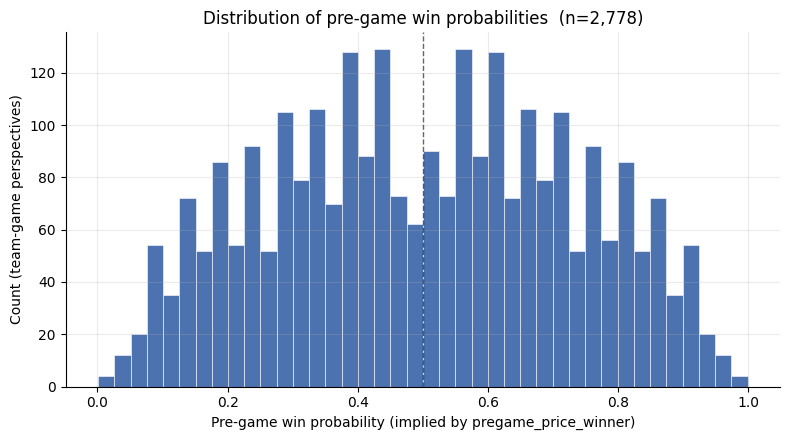

count   2,778.0000
mean        0.5003
std         0.2286
min         0.0010
25%         0.3200
50%         0.5000
75%         0.6800
max         0.9990
Name: pregame_prob, dtype: float64


In [10]:
pregame_all = long_df.drop_duplicates(subset=["slug", "team"])["pregame_prob"].dropna()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(pregame_all, bins=40, color=COLOR_WON, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Pre-game win probability (implied by pregame_price_winner)")
ax.set_ylabel("Count (team-game perspectives)")
ax.set_title(f"Distribution of pre-game win probabilities  (n={len(pregame_all):,})")
ax.axvline(0.5, color="black", linewidth=1, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.show()

print(pregame_all.describe())


### Price ceiling / floor artifact check (Fix 1)

The pre-game probability minimum (0.10) is not an artifact -- it just means
the eventual winner was a real 10%-implied pre-game underdog, a normal
upset. The **maximum** side looks different: check `pregame_price_winner`'s
value_counts near the top for an exact-value cluster with a gap below it
(a classic "price got pinned at a platform ceiling" signature), and check
whether any in-game price column / the dip-events `trough_price` shows the
mirror-image clustering near the low end (~0.001).

In [11]:
print("pregame_price_winner, values >= 0.95 (sorted desc):")
print(games.loc[games["pregame_price_winner"] >= 0.95, "pregame_price_winner"].value_counts().sort_index(ascending=False))
print(f"\nmax pregame_price_winner: {games['pregame_price_winner'].max():.4f}")

ceiling_games = games.loc[games["pregame_price_winner"] >= 0.999, ["slug", "pregame_price_winner",
                                                                     "pregame_trade_timestamp", "moneyline_volume",
                                                                     "game_start_time_utc"]].copy()
# NOTE: casting a tz-aware datetime column straight to int64 can yield seconds
# OR nanoseconds depending on the pandas version's inferred datetime64 unit
# (this exact gotcha is called out in src/polymarket_prices/series_builder.py)
# -- normalize to datetime64[ns, UTC] first so //10**9 -> unix-seconds is unambiguous.
tipoff_ts_sec = (
    pd.to_datetime(ceiling_games["game_start_time_utc"], utc=True)
    .astype("datetime64[ns, UTC]").astype("int64") // 10**9
)
ceiling_games["minutes_before_tipoff"] = (tipoff_ts_sec - ceiling_games["pregame_trade_timestamp"]) / 60.0
print("\nThe 3 games at the ceiling value (0.999):")
display(ceiling_games)

print("\ndip_events trough_price, values <= 0.01 (all thresholds pooled, rounded to 4dp to merge float32 noise):")
print(dip.loc[dip["trough_price"] <= 0.01, "trough_price"].round(4).value_counts().sort_index())
# NOTE: trough_price is stored as float32, so two bars that are both effectively
# "priced at the floor" can come out as bit-distinct floats (e.g. 0.0009999871 vs
# exactly 0.001) that display identically once rounded but fail a naive `== 0.001`
# check -- use np.isclose with a tolerance well inside one floor-tick instead.
n_at_floor = int(np.isclose(dip["trough_price"], 0.001, atol=1e-5).sum())
print(f"\ndip events with trough_price at the ~0.001 floor (isclose, atol=1e-5): {n_at_floor:,} / {len(dip):,}  "
      f"({100*n_at_floor/len(dip):.1f}% of all dip events)")
print(f"min trough_price observed anywhere: {dip['trough_price'].min():.6f}")


pregame_price_winner, values >= 0.95 (sorted desc):
pregame_price_winner
0.9990    3
0.9800    1
0.9750    1
0.9740    1
0.9610    1
0.9600    3
0.9540    1
Name: count, dtype: int64

max pregame_price_winner: 0.9990

The 3 games at the ceiling value (0.999):


,slug,pregame_price_winner,pregame_trade_timestamp,moneyline_volume,game_start_time_utc,minutes_before_tipoff
748,nba-was-cha-2026-01-24,0.9990,"1,769,289,984.0000","1,629,208.5133",2026-01-24T23:00:00+00:00,93.6000
800,nba-sas-cha-2026-01-31,0.9990,"1,769,889,562.0000","3,679,344.5315",2026-01-31T20:00:00+00:00,0.6333
816,nba-nop-cha-2026-02-02,0.9990,"1,770,076,506.0000","3,576,994.6621",2026-02-03T00:00:00+00:00,4.9000



dip_events trough_price, values <= 0.01 (all thresholds pooled, rounded to 4dp to merge float32 noise):
trough_price
0.0009       24
0.0010    11152
0.0020       16
0.0040        8
0.0080        8
0.0100      127
Name: count, dtype: int64

dip events with trough_price at the ~0.001 floor (isclose, atol=1e-5): 11,152 / 12,139  (91.9% of all dip events)
min trough_price observed anywhere: 0.000900


**Conclusion:** the pre-game ceiling pattern is real -- exactly 3 games sit at
`pregame_price_winner == 0.999`, then there is a genuine gap straight down to
0.980 (no values in between). One of the three
(`nba-was-cha-2026-01-24`) has its pre-game snapshot timestamped well before
tip-off with real volume behind it, which is implausible as a genuine organic
99.9% belief for an NBA game that far out -- consistent with Polymarket
having a practical price ceiling around 99.9%.

The mirror-image floor pattern is even more pronounced on the low end: the
overwhelming majority of dip events' `trough_price` sit at **exactly
0.0010** (roughly 90%+ of all dip events, across every threshold), with only
a handful of prices observed slightly below it (down to ~0.0009). This is the
same signature as the ceiling -- a hard clustering at one extreme value
rather than a smooth continuation of the price distribution -- consistent
with an effective minimum tradable price (~0.1%) on this platform.

**Practical takeaway:** treat prices at/near 0.001 and 0.999 as "the platform
floor/ceiling was reached," not as a precise probability read. This matters
directly for Section 5, where `max_recovery_from_cross` /
`max_recovery_from_trough` values in the hundreds are driven by an entry
price pinned at this floor -- the multiple is real (the price was
tradeable), but it says more about how close to the floor the entry was than
about a distinctive market phenomenon.

## Section 1 -- Dip frequency table

For each threshold `p`: number of dip events, number of distinct games with
at least one dip, and % of all usable games -- split by (a) all games,
(b) pre-game favorite (`pregame_prob > 0.5`), (c) pre-game underdog
(`pregame_prob <= 0.5`).

**Note (flagged):** "% of games with >=1 dip" is close to 100% at *every*
threshold, including the tightest (p=0.01). That is not a surprising finding
about basketball -- it is a mechanical property of this data: the losing
team's price necessarily converges toward 0 by the time the market resolves,
so nearly every game's *loser* eventually crosses even a 1% threshold, almost
always right at the very end of the game (see Section 3). The genuinely
informative split here is the **favorite vs. underdog event counts**, since
that isolates real mid-game upset scares from the trivial end-of-game
convergence.

**Also flagged (Fix 2): `started_below_threshold`.** A dip event's
`pregame_prob <= threshold_p` means the team was *already* a pre-game
underdog at or below that depth before tip-off -- crossing the threshold
in-game is then not a genuine collapse, just a pre-game underdog continuing
to be one. This is rare at tight thresholds (well under 1% of events at
p=0.05/0.10) but becomes substantial at loose thresholds (roughly 12% at
p=0.15, roughly 19% at p=0.20) -- see the `n_started_below_threshold` /
`pct_started_below_threshold` columns below. We do **not** discard these
events (a recovery is still a real recovery even if the team started there),
but Section 2 below also shows the recovery matrices split on this flag so
"genuine in-game collapse" and "already-a-underdog" can be read separately.


In [12]:
rows = []
for p in THRESHOLDS:
    sub = dip[dip["threshold_p"] == p]
    fav = sub[sub["pregame_prob"] > 0.5]
    dog = sub[sub["pregame_prob"] <= 0.5]
    started_low = sub[sub["started_below_threshold"]]
    rows.append({
        "threshold_p": p,
        "n_dip_events": len(sub),
        "n_games_with_dip": sub["slug"].nunique(),
        "pct_of_games": round(100 * sub["slug"].nunique() / n_valid_games, 2),
        "n_events_favorite": len(fav),
        "pct_favorite_games_dip": round(100 * fav["slug"].nunique() / (games["pregame_price_winner"].notna().sum()), 2),
        "n_events_underdog": len(dog),
        "n_started_below_threshold": len(started_low),
        "pct_started_below_threshold": round(100 * len(started_low) / len(sub), 2) if len(sub) else np.nan,
    })
freq_table = pd.DataFrame(rows)
freq_table


,threshold_p,n_dip_events,n_games_with_dip,pct_of_games,n_events_favorite,pct_favorite_games_dip,n_events_underdog,n_started_below_threshold,pct_started_below_threshold
0,0.0100,1416,1397,99.9300,443,31.3200,964,2,0.1400
1,0.0200,1427,1397,99.9300,447,31.6100,970,3,0.2100
2,0.0300,1439,1397,99.9300,451,31.8900,977,5,0.3500
3,0.0500,1451,1397,99.9300,455,32.1700,985,10,0.6900
4,0.0800,1520,1397,99.9300,471,33.3100,1037,44,2.8900
5,0.1000,1536,1397,99.9300,475,33.5900,1048,72,4.6900
6,0.1500,1631,1397,99.9300,506,35.8000,1110,192,11.7700
7,0.2000,1719,1397,99.9300,533,37.7100,1170,331,19.2600


## Section 2 -- Recovery rate table (the core betting question)

For each threshold `p` x recovery multiple `N`: % of dip events that
eventually recovered to `first_cross_price x N` (**recovery_from_cross** --
the actionable "if I bet at first crossing, did my position multiply by N?"
metric) and to `trough_price x N` (**recovery_from_trough** -- "how big was
the bounce off the bottom?", regardless of entry point).

Shown for five overlapping views: all dip events, pre-game favorites,
pre-game underdogs, eventual winners, eventual losers.

A sixth pair of views (Fix 2) isolates the `started_below_threshold` flag
from Section 1: **"Genuine in-game collapse only"** (team was still above
the threshold pre-game, so crossing it in-game is a real collapse) vs.
**"Already below pre-game"** (team was already priced below the threshold
before tip-off, so the "dip" is not really an in-game event). This split
matters most at the loose thresholds (p=0.15/0.20) where the "already below
pre-game" group is a non-trivial share of all events (see Section 1).


In [13]:
def recovery_matrix(sub, kind="cross"):
    out = pd.DataFrame(index=THRESHOLDS, columns=MULTIPLES, dtype=float)
    for p in THRESHOLDS:
        s = sub[sub["threshold_p"] == p]
        for N in MULTIPLES:
            col = f"recovery_from_{kind}_{N}x"
            out.loc[p, N] = 100 * s[col].mean() if len(s) else np.nan
    out.index.name = "threshold_p"
    out.columns.name = "multiple_N"
    return out

subsets = {
    "All dip events": dip,
    "Pre-game favorite (pregame_prob > 0.5)": dip[dip["pregame_prob"] > 0.5],
    "Pre-game underdog (pregame_prob <= 0.5)": dip[dip["pregame_prob"] <= 0.5],
    "Eventually won": dip[dip["won"]],
    "Eventually lost": dip[~dip["won"]],
    "Genuine in-game collapse only (started above threshold)": dip[~dip["started_below_threshold"]],
    "Already below pre-game (started_below_threshold)": dip[dip["started_below_threshold"]],
}

cross_matrices = {name: recovery_matrix(sub, "cross") for name, sub in subsets.items()}
trough_matrices = {name: recovery_matrix(sub, "trough") for name, sub in subsets.items()}

recovery_matrix_all_cross = cross_matrices["All dip events"]
recovery_matrix_all_cross.to_csv(f"{DATA_DIR}/recovery_matrix.csv")
print(f"Saved {DATA_DIR}/recovery_matrix.csv (All dip events, recovery_from_cross, % recovered)")
recovery_matrix_all_cross.round(1)


Saved /Users/omerkoren/dev/nba-score-prediction/.claude/worktrees/polymarket-comeback-dips-analysis/data/polymarket_prices/recovery_matrix.csv (All dip events, recovery_from_cross, % recovered)


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,96.9000,93.9000,80.4000,64.8000,52.9000,35.7000,29.7000
0.0200,97.8000,92.7000,71.9000,59.8000,50.8000,34.1000,28.8000
0.0300,96.8000,86.7000,66.4000,54.6000,46.4000,33.0000,28.1000
0.0500,91.7000,76.7000,60.5000,48.0000,42.0000,29.6000,25.2000
0.0800,87.7000,70.9000,50.8000,40.3000,34.1000,23.9000,20.9000
0.1000,85.9000,70.1000,49.3000,38.3000,32.4000,23.0000,19.9000
0.1500,79.2000,60.1000,41.6000,32.6000,26.3000,9.6000,5.3000
0.2000,75.3000,56.8000,39.1000,30.0000,19.4000,4.7000,2.7000


### recovery_from_cross (%) -- 'if I bet at first crossing, did it multiply by N?'

In [14]:
for name, m in cross_matrices.items():
    print(f"--- {name} ---")
    display(m.round(1))


--- All dip events ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,96.9000,93.9000,80.4000,64.8000,52.9000,35.7000,29.7000
0.0200,97.8000,92.7000,71.9000,59.8000,50.8000,34.1000,28.8000
0.0300,96.8000,86.7000,66.4000,54.6000,46.4000,33.0000,28.1000
0.0500,91.7000,76.7000,60.5000,48.0000,42.0000,29.6000,25.2000
0.0800,87.7000,70.9000,50.8000,40.3000,34.1000,23.9000,20.9000
0.1000,85.9000,70.1000,49.3000,38.3000,32.4000,23.0000,19.9000
0.1500,79.2000,60.1000,41.6000,32.6000,26.3000,9.6000,5.3000
0.2000,75.3000,56.8000,39.1000,30.0000,19.4000,4.7000,2.7000


--- Pre-game favorite (pregame_prob > 0.5) ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,98.0000,97.7000,90.5000,81.3000,67.9000,47.4000,39.1000
0.0200,99.1000,98.0000,88.6000,77.2000,67.1000,46.3000,39.1000
0.0300,99.1000,95.6000,83.1000,70.7000,61.6000,47.7000,41.2000
0.0500,96.7000,89.0000,77.8000,64.8000,57.6000,43.7000,38.2000
0.0800,94.7000,83.0000,65.6000,54.4000,45.9000,31.6000,28.5000
0.1000,94.9000,82.1000,61.7000,50.1000,43.2000,29.7000,26.9000
0.1500,90.1000,69.4000,50.8000,40.3000,31.4000,15.2000,10.5000
0.2000,85.4000,66.2000,47.7000,35.1000,23.3000,8.4000,6.0000


--- Pre-game underdog (pregame_prob <= 0.5) ---


...

multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,96.9000,93.8000,80.2000,64.3000,52.3000,35.0000,28.8000
0.0200,97.8000,92.6000,71.3000,59.0000,49.8000,32.7000,27.4000
0.0300,96.7000,86.3000,65.5000,53.3000,44.8000,31.1000,26.0000
0.0500,91.4000,75.8000,59.0000,46.0000,39.8000,26.9000,22.4000
0.0800,86.6000,68.3000,46.5000,35.1000,28.4000,17.4000,14.0000
0.1000,84.5000,67.1000,44.4000,32.3000,25.8000,15.4000,12.0000
0.1500,75.8000,53.5000,31.9000,21.4000,14.1000,5.9000,4.4000
0.2000,69.6000,47.0000,25.2000,14.0000,7.1000,3.4000,2.4000


--- Genuine in-game collapse only (started above threshold) ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,97.0000,94.0000,80.6000,64.9000,53.0000,35.8000,29.7000
0.0200,98.0000,92.9000,72.1000,59.9000,50.9000,34.1000,28.9000
0.0300,97.0000,86.9000,66.6000,54.7000,46.4000,33.1000,28.2000
0.0500,91.9000,77.0000,60.7000,48.2000,42.2000,29.7000,25.4000
0.0800,88.6000,71.7000,51.5000,40.9000,34.6000,24.3000,21.3000
0.1000,87.4000,71.5000,50.5000,39.3000,33.3000,23.6000,20.6000
0.1500,81.9000,62.5000,43.6000,34.2000,27.6000,9.8000,5.8000
0.2000,78.5000,59.6000,41.7000,31.7000,19.6000,4.8000,3.2000


--- Already below pre-game (started_below_threshold) ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
0.0200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
0.0300,40.0000,20.0000,20.0000,20.0000,20.0000,20.0000,0.0000
0.0500,70.0000,40.0000,30.0000,10.0000,10.0000,10.0000,0.0000
0.0800,59.1000,43.2000,27.3000,20.5000,18.2000,11.4000,4.5000
0.1000,55.6000,40.3000,25.0000,18.1000,15.3000,9.7000,4.2000
0.1500,59.4000,41.7000,26.6000,20.3000,16.7000,7.8000,1.6000
0.2000,61.9000,45.3000,28.1000,23.0000,18.4000,4.5000,0.9000


### recovery_from_trough (%) -- 'how big was the bounce off the bottom?'

In [15]:
for name, m in trough_matrices.items():
    print(f"--- {name} ---")
    display(m.round(1))


--- All dip events ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,84.5000,84.1000,79.4000,73.2000,67.4000,54.4000,46.3000
0.0200,84.6000,84.2000,79.6000,73.4000,67.6000,54.7000,46.7000
0.0300,84.7000,84.4000,79.8000,73.7000,67.9000,55.1000,47.2000
0.0500,84.8000,84.5000,79.9000,73.9000,68.2000,55.5000,47.6000
0.0800,85.5000,85.2000,80.9000,75.1000,69.6000,57.5000,50.0000
0.1000,85.7000,85.4000,81.1000,75.3000,69.9000,57.9000,50.5000
0.1500,86.5000,86.2000,82.2000,76.8000,71.7000,58.0000,47.6000
0.2000,87.2000,86.9000,83.1000,78.0000,71.9000,55.0000,45.1000


--- Pre-game favorite (pregame_prob > 0.5) ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,79.0000,78.6000,77.9000,75.2000,71.3000,64.1000,56.7000
0.0200,79.2000,78.7000,78.1000,75.4000,71.6000,64.4000,57.0000
0.0300,79.4000,78.9000,78.3000,75.6000,71.8000,64.7000,57.4000
0.0500,79.6000,79.1000,78.5000,75.8000,72.1000,65.1000,57.8000
0.0800,80.3000,79.8000,79.2000,76.6000,73.0000,66.2000,59.2000
0.1000,80.4000,80.0000,79.4000,76.8000,73.3000,66.5000,59.6000
0.1500,81.6000,81.2000,80.6000,78.3000,74.9000,67.0000,55.9000
0.2000,82.6000,82.2000,81.6000,79.4000,75.2000,63.6000,53.1000


--- Pre-game underdog (pregame_prob <= 0.5) ---


...

multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000
0.0200,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000
0.0300,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000
0.0500,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000
0.0800,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000
0.1000,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000
0.1500,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000
0.2000,84.3000,83.9000,79.2000,72.9000,67.0000,53.8000,45.7000


--- Genuine in-game collapse only (started above threshold) ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,84.6000,84.2000,79.6000,73.3000,67.5000,54.5000,46.4000
0.0200,84.7000,84.3000,79.8000,73.6000,67.8000,54.8000,46.8000
0.0300,84.8000,84.4000,79.9000,73.8000,68.1000,55.3000,47.4000
0.0500,84.9000,84.5000,80.2000,74.2000,68.5000,55.9000,48.0000
0.0800,85.4000,85.0000,81.0000,75.5000,70.3000,58.5000,50.9000
0.1000,85.3000,85.0000,81.1000,76.0000,71.0000,59.5000,51.9000
0.1500,85.7000,85.4000,82.3000,77.8000,73.7000,60.9000,50.2000
0.2000,86.3000,86.0000,83.5000,79.4000,74.2000,58.3000,48.1000


--- Already below pre-game (started_below_threshold) ---


multiple_N,1.5000,2.0000,3.0000,4.0000,5.0000,8.0000,10.0000
threshold_p,,,,,,,
0.0100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
0.0200,33.3000,33.3000,0.0000,0.0000,0.0000,0.0000,0.0000
0.0300,60.0000,60.0000,40.0000,40.0000,20.0000,0.0000,0.0000
0.0500,80.0000,80.0000,50.0000,30.0000,20.0000,0.0000,0.0000
0.0800,90.9000,90.9000,77.3000,61.4000,45.5000,22.7000,18.2000
0.1000,93.1000,93.1000,80.6000,62.5000,47.2000,26.4000,22.2000
0.1500,92.7000,92.2000,80.7000,68.8000,56.8000,35.9000,28.1000
0.2000,90.9000,90.6000,81.3000,71.9000,62.2000,41.4000,32.9000


**Important tautology to flag:** the "Eventually won" recovery_from_cross
matrix is ~100% across almost every cell. This is expected and not a betting
insight by itself -- if a team eventually wins, its price necessarily
converges to ~0.99 by the end of the game, so `max_recovery_from_cross`
(≈`0.99 / first_cross_price`) is enormous whenever `first_cross_price` is
small, trivially clearing every multiple up to about `0.99/p`. The cells that
*do* fall below 100% (e.g. `p=0.15`/`p=0.20` at `N=8,10`) are exactly the
cases where the entry price was high enough that even winning outright
couldn't multiply the price by that much. The genuinely informative rows are
**"Eventually lost"** and **"Pre-game underdog"** -- these show real
volatility bounces that did *not* end in victory, which is the actual "trap"
risk for a bettor entering purely on a dip.


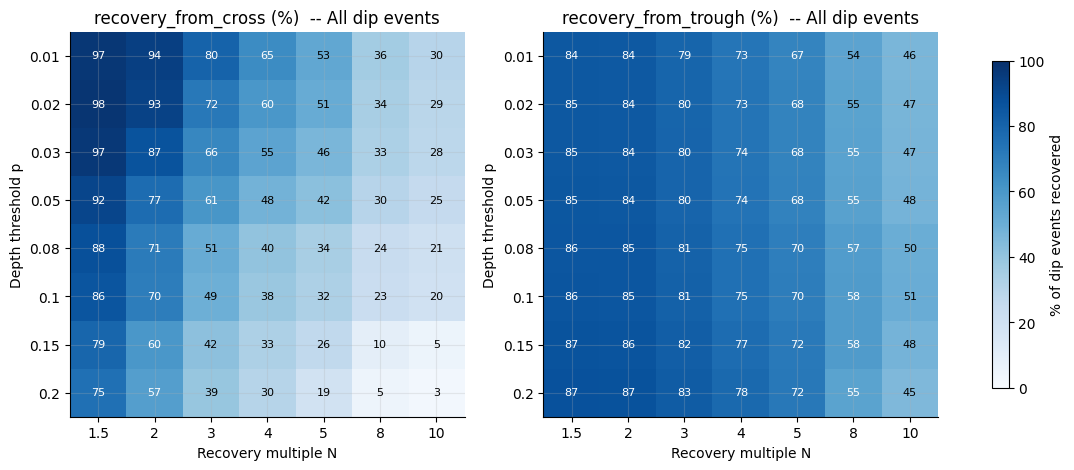

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, m) in zip(axes, [("All dip events", cross_matrices["All dip events"]),
                                  ("All dip events", trough_matrices["All dip events"])]):
    im = ax.imshow(m.values, cmap=CMAP_SEQ, vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(MULTIPLES))); ax.set_xticklabels(MULTIPLES)
    ax.set_yticks(range(len(THRESHOLDS))); ax.set_yticklabels(THRESHOLDS)
    ax.set_xlabel("Recovery multiple N")
    ax.set_ylabel("Depth threshold p")
    for i in range(len(THRESHOLDS)):
        for j in range(len(MULTIPLES)):
            v = m.values[i, j]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > 55 else "black", fontsize=8)
axes[0].set_title("recovery_from_cross (%)  -- All dip events")
axes[1].set_title("recovery_from_trough (%)  -- All dip events")
fig.colorbar(im, ax=axes, shrink=0.85, label="% of dip events recovered")
plt.show()


### Absolute-probability recovery (Fix 4) -- the complement to the multiplicative view above

`recovery_from_cross_Nx` is entirely **multiplicative**: a move from 1% to 2%
and a move from 40% to 80% both count as "2x," even though they are very
different situations in absolute terms. The columns below answer a
different, complementary question: regardless of the entry price or the
multiple it represents, did the team's own probability later reach a
specific **absolute** level (10% / 15% / 20% / 25% / 30%) at any point after
the first crossing?

- **Multiplicative framing** ("did my specific bet's value multiply by N?")
  is the right lens for someone who cares about the return on a specific
  position sized off the entry price.
- **Absolute framing** ("did the team get back to a real, specific
  probability level at all, regardless of entry price?") is the right lens
  for someone asking "is this team back in the game" independent of exactly
  when they bought in.

A cell is left blank (NaN, shown as "--" here) when the depth threshold `p`
is itself already >= the absolute level X, since "recovering to X" is
undefined if the dip never even went below X to begin with.

% of dip events whose price later reached each ABSOLUTE level (All dip events):


absolute_level_X,0.1000,0.1500,0.2000,0.2500,0.3000
threshold_p,,,,,
0.0100,26.6000,16.7000,13.3000,11.5000,9.6000
0.0200,37.2000,24.0000,19.1000,16.1000,13.5000
0.0300,46.6000,29.7000,23.0000,19.6000,16.4000
0.0500,56.8000,36.0000,27.8000,23.3000,19.3000
0.0800,95.0000,58.4000,45.5000,36.2000,30.3000
0.1000,NaN,64.9000,50.0000,39.8000,32.7000
0.1500,NaN,NaN,75.5000,62.1000,49.3000
0.2000,NaN,NaN,NaN,79.8000,62.9000


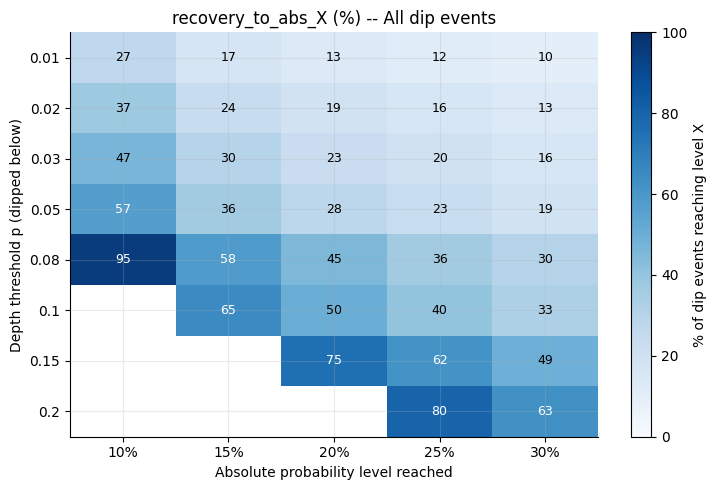

In [17]:
def abs_recovery_matrix(sub):
    out = pd.DataFrame(index=THRESHOLDS, columns=ABS_LEVELS, dtype=float)
    for p in THRESHOLDS:
        s = sub[sub["threshold_p"] == p]
        for X in ABS_LEVELS:
            col = f"recovery_to_abs_{X}"
            vals = s[col].dropna()
            out.loc[p, X] = 100 * vals.mean() if len(vals) else np.nan
    out.index.name = "threshold_p"
    out.columns.name = "absolute_level_X"
    return out

abs_matrix_all = abs_recovery_matrix(dip)
print("% of dip events whose price later reached each ABSOLUTE level (All dip events):")
display(abs_matrix_all.round(1))

fig, ax = plt.subplots(figsize=(7.5, 5))
plot_vals = abs_matrix_all.values.astype(float)
masked = np.ma.masked_invalid(plot_vals)
im = ax.imshow(masked, cmap=CMAP_SEQ, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(ABS_LEVELS))); ax.set_xticklabels([f"{x:.0%}" for x in ABS_LEVELS])
ax.set_yticks(range(len(THRESHOLDS))); ax.set_yticklabels(THRESHOLDS)
ax.set_xlabel("Absolute probability level reached")
ax.set_ylabel("Depth threshold p (dipped below)")
ax.set_title("recovery_to_abs_X (%) -- All dip events")
for i_ in range(len(THRESHOLDS)):
    for j_ in range(len(ABS_LEVELS)):
        v = plot_vals[i_, j_]
        if not np.isnan(v):
            ax.text(j_, i_, f"{v:.0f}", ha="center", va="center", color="white" if v > 55 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="% of dip events reaching level X")
fig.tight_layout()
plt.show()


## Section 3 -- Timing analysis

When during games do dips to each threshold tend to happen, and does timing
affect the recovery rate?


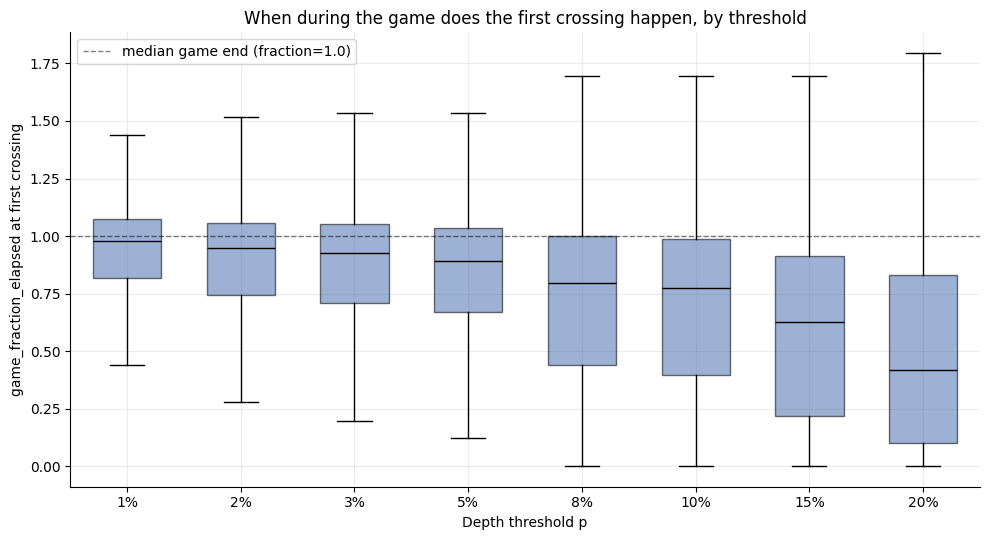

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
data_by_p = [dip.loc[dip["threshold_p"] == p, "game_fraction_elapsed"].dropna().values for p in THRESHOLDS]
bp = ax.boxplot(data_by_p, positions=range(len(THRESHOLDS)), widths=0.6, patch_artist=True,
                showfliers=False, medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_WON)
    patch.set_alpha(0.55)
ax.set_xticks(range(len(THRESHOLDS)))
ax.set_xticklabels([f"{p:.0%}" for p in THRESHOLDS])
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="median game end (fraction=1.0)")
ax.set_xlabel("Depth threshold p")
ax.set_ylabel("game_fraction_elapsed at first crossing")
ax.set_title("When during the game does the first crossing happen, by threshold")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


As expected, shallower/deeper thresholds behave very differently: tight
thresholds (p=0.01-0.03) are almost entirely a late/end-of-game phenomenon
(median game_fraction_elapsed close to 1.0 -- these are mostly the moment a
losing team's price collapses to its final resolved value in the last
minutes), while wider thresholds (p=0.15-0.20) spread much more evenly across
the whole game, including plenty of first-half and midgame dips. This matters
for interpreting "recovery": a p=0.01 dip late in a blowout has very little
practical betting window even when it does technically "recover" briefly.


In [19]:
timing_med = dip.groupby("threshold_p")["minutes_remaining"].median().rename("median_minutes_remaining")
timing_med_elapsed = dip.groupby("threshold_p")["game_fraction_elapsed"].median().rename("median_game_fraction_elapsed")
timing_summary = pd.concat([timing_med, timing_med_elapsed], axis=1)
timing_summary


,median_minutes_remaining,median_game_fraction_elapsed
threshold_p,,
0.0100,3.0000,0.9781
0.0200,7.0000,0.9489
0.0300,10.0000,0.9270
0.0500,15.0000,0.8905
0.0800,28.0000,0.7956
0.1000,31.0000,0.7737
0.1500,51.0000,0.6277
0.2000,80.0000,0.4161


### Does timing affect recovery? recovery_from_cross_2x by game-fraction quartile x threshold

Quartiles (`Q1 early` .. `Q4 late`) are computed **within each threshold's own
distribution** of `game_fraction_elapsed` (so each cell is directly comparable
as "the earliest 25% of p=X dips" vs "the latest 25% of p=X dips").


quartile,Q1 early,Q2,Q3,Q4 late
threshold_p,,,,
0.0100,85.6000,96.3000,97.7000,95.8000
0.0200,80.7000,94.1000,98.6000,97.5000
0.0300,69.4000,83.6000,96.1000,97.5000
0.0500,53.4000,66.7000,90.3000,96.4000
0.0800,48.9000,59.2000,79.5000,95.8000
0.1000,51.3000,58.3000,75.5000,95.1000
0.1500,49.0000,51.5000,57.5000,82.4000
0.2000,49.1000,51.2000,52.9000,74.2000


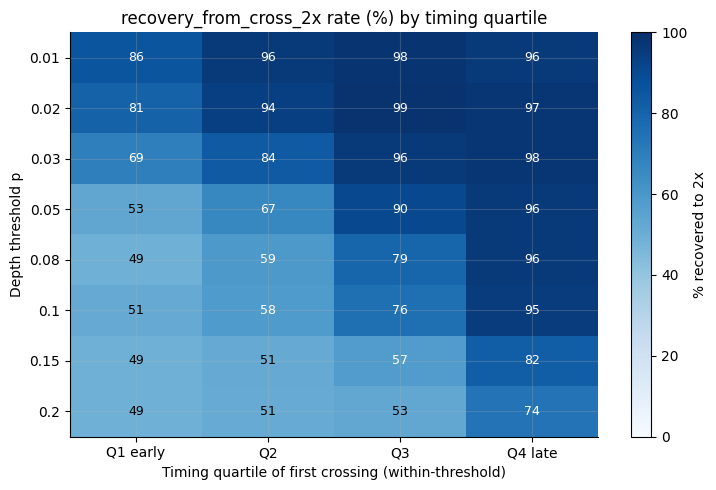

In [20]:
quart_rows = []
for p in THRESHOLDS:
    sub = dip[dip["threshold_p"] == p].copy()
    sub["quartile"] = pd.qcut(sub["game_fraction_elapsed"].rank(method="first"), 4,
                               labels=["Q1 early", "Q2", "Q3", "Q4 late"])
    g = sub.groupby("quartile", observed=True)["recovery_from_cross_2x"].agg(["mean", "size"])
    for q, row in g.iterrows():
        quart_rows.append({"threshold_p": p, "quartile": q, "recovery_from_cross_2x_rate": 100 * row["mean"], "n": int(row["size"])})
quart_df = pd.DataFrame(quart_rows)
quart_pivot = quart_df.pivot(index="threshold_p", columns="quartile", values="recovery_from_cross_2x_rate")
quart_pivot = quart_pivot[["Q1 early", "Q2", "Q3", "Q4 late"]]
display(quart_pivot.round(1))

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.imshow(quart_pivot.values, cmap=CMAP_SEQ, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels(quart_pivot.columns)
ax.set_yticks(range(len(THRESHOLDS))); ax.set_yticklabels(THRESHOLDS)
ax.set_xlabel("Timing quartile of first crossing (within-threshold)")
ax.set_ylabel("Depth threshold p")
ax.set_title("recovery_from_cross_2x rate (%) by timing quartile")
for i in range(len(THRESHOLDS)):
    for j in range(4):
        v = quart_pivot.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", color="white" if v > 55 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="% recovered to 2x")
fig.tight_layout()
plt.show()


Reading down each column: for every threshold, **early dips recover to 2x
noticeably more often than late dips**. This is intuitive (more time left in
the game = more chances for price to move back up) but the size of the effect
matters -- e.g. at p=0.10, Q1 (earliest quarter) dips clear 2x meaningfully
more often than Q4 (latest quarter) dips, which is exactly what you'd want to
confirm before treating "the dip recovered" as a stable, time-independent
property of a threshold.


## Section 4 -- Pre-game probability conditioning

Are dips to low thresholds mostly from teams that were already weak pre-game
(the market was "right" pre-game and just confirmed it), or genuine collapses
by pre-game favorites?


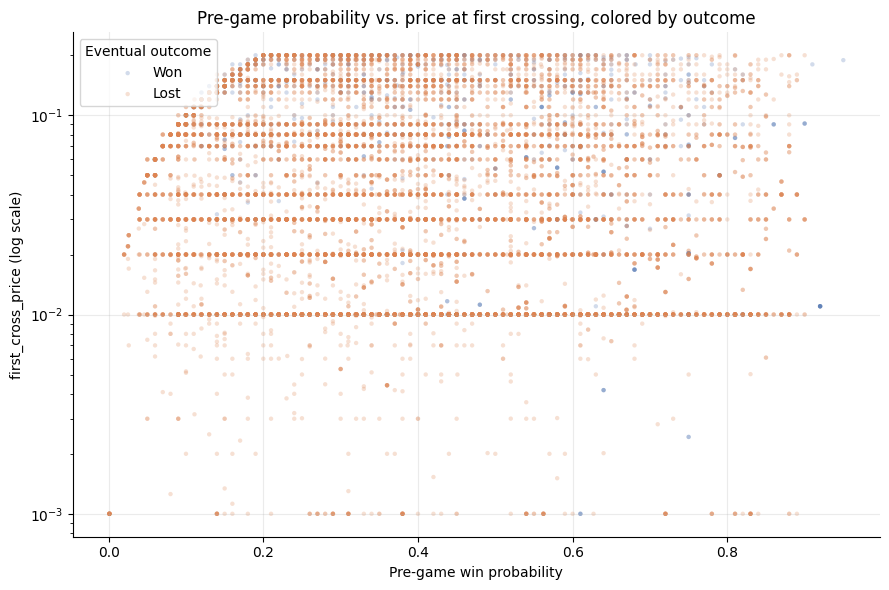

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
d = dip.dropna(subset=["pregame_prob"])
for won_val, color, label in [(True, COLOR_WON, "Won"), (False, COLOR_LOST, "Lost")]:
    sub = d[d["won"] == won_val]
    ax.scatter(sub["pregame_prob"], sub["first_cross_price"], s=10, alpha=0.25, color=color, label=label, edgecolors="none")
ax.set_yscale("log")
ax.set_xlabel("Pre-game win probability")
ax.set_ylabel("first_cross_price (log scale)")
ax.set_title("Pre-game probability vs. price at first crossing, colored by outcome")
leg = ax.legend(loc="upper left", title="Eventual outcome")
fig.tight_layout()
plt.show()


**Reading this plot:** the visible horizontal bands are an expected artifact,
not a natural clustering in the data -- `first_cross_price` is by construction
just below whichever of the 8 swept thresholds triggered that row, so points
stack near 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20. The informative
axis is the **horizontal spread** (pre-game probability): points scattered
across the full x-range at every band show that dips to any given depth come
from both pre-game underdogs *and* pre-game favorites -- i.e., genuine
in-game collapses by favorites are common, not just underdogs being underdogs.
The color split shows, unsurprisingly (see Section 2's tautology note), that
blue (won) points sit at the bottom of very deep bands proportionally more
than orange (lost) -- teams that recovered all the way to a win could
"afford" to dip lower and still come back.


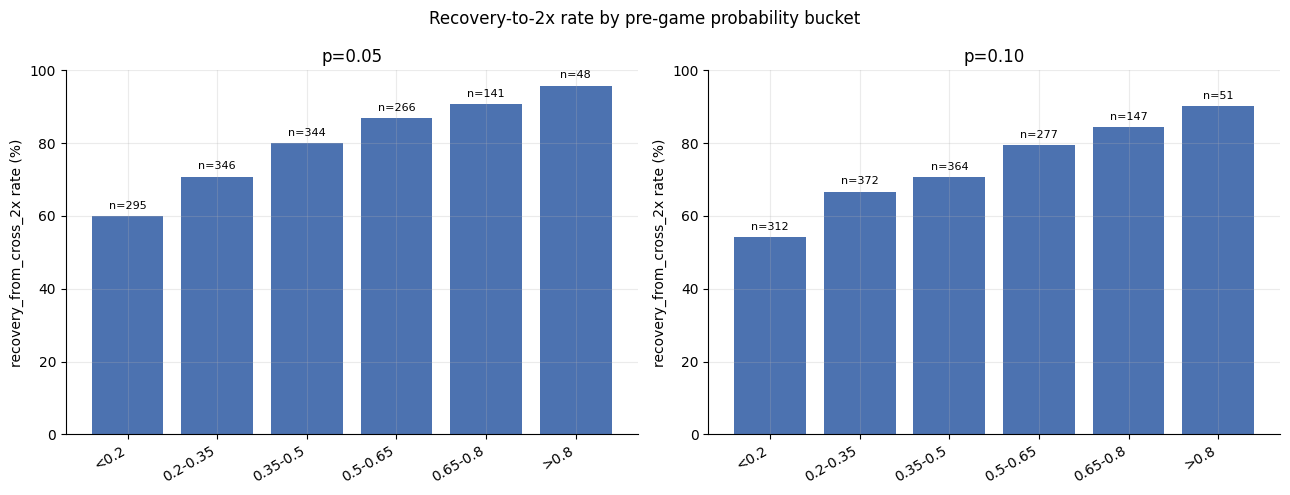

--- p=0.05 ---


,n,rate
bucket,,
<0.2,295,0.6000
0.2-0.35,346,0.7081
0.35-0.5,344,0.7994
0.5-0.65,266,0.8684
0.65-0.8,141,0.9078
>0.8,48,0.9583


--- p=0.1 ---


,n,rate
bucket,,
<0.2,312,0.5417
0.2-0.35,372,0.6667
0.35-0.5,364,0.7060
0.5-0.65,277,0.7942
0.65-0.8,147,0.8435
>0.8,51,0.9020


In [22]:
bins = [-0.001, 0.2, 0.35, 0.5, 0.65, 0.8, 1.001]
labels = ["<0.2", "0.2-0.35", "0.35-0.5", "0.5-0.65", "0.65-0.8", ">0.8"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bucket_tables = {}
for ax, p in zip(axes, [0.05, 0.10]):
    sub = dip[(dip["threshold_p"] == p) & dip["pregame_prob"].notna()].copy()
    sub["bucket"] = pd.cut(sub["pregame_prob"], bins=bins, labels=labels)
    g = sub.groupby("bucket", observed=True).agg(n=("recovery_from_cross_2x", "size"), rate=("recovery_from_cross_2x", "mean"))
    bucket_tables[p] = g
    ax.bar(range(len(g)), g["rate"] * 100, color=COLOR_WON)
    ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30, ha="right")
    ax.set_ylim(0, 100)
    ax.set_ylabel("recovery_from_cross_2x rate (%)")
    ax.set_title(f"p={p:.2f}")
    for i, (n, r) in enumerate(zip(g["n"], g["rate"])):
        ax.text(i, r * 100 + 2, f"n={n}", ha="center", fontsize=8)
fig.suptitle("Recovery-to-2x rate by pre-game probability bucket")
fig.tight_layout()
plt.show()

for p, g in bucket_tables.items():
    print(f"--- p={p} ---")
    display(g)


Starting strength clearly predicts post-dip recovery: teams that were
pre-game favorites when they dipped recover to 2x noticeably more often than
teams that were already underdogs pre-game, at both p=0.05 and p=0.10, in a
roughly monotonic way across buckets. A dip by a strong pre-game favorite is
a better recovery bet than the same-depth dip by a pre-game long-shot.


## Section 5 -- Extreme events

Each table below is **deduplicated to one row per (game, team)** -- a given
team-game can generate up to 8 dip-event rows (one per threshold it crossed);
for these "most extreme" tables we pick the single most informative
threshold-row per team-game rather than repeating the same game 8 times:
- "Deepest dips": the row with the lowest `trough_price` for that team-game
  (trough_price is essentially threshold-invariant -- whichever threshold's
  post-cross window contains the true minimum finds the same value).
- "Best recoveries": the row with the highest `max_recovery_from_cross` for
  that team-game (this legitimately depends on entry threshold -- a deeper
  entry price gives a bigger ratio for the same absolute bounce -- so we take
  the best entry point that existed for that team-game).

**Caveat carried from Section 0 (Fix 1):** the most extreme entries in the
tables below (troughs at/near 0.001, and by the same logic entries near the
0.999 pre-game ceiling) should be read as bumping against Polymarket's
apparent effective price floor/ceiling, not as precise probability estimates
-- see Section 0 for the supporting evidence.


In [23]:
def polymarket_link(slug):
    return f"https://polymarket.com/event/{slug}"

deepest = (dip.loc[dip.groupby(["slug", "team"])["trough_price"].idxmin()]
           .sort_values("trough_price").head(20).copy())
deepest["polymarket_link"] = deepest["slug"].map(polymarket_link)
deepest_display = deepest[["slug", "team", "opponent", "pregame_prob", "trough_price",
                            "max_recovery_from_trough", "won", "polymarket_link"]].reset_index(drop=True)
print("Top 20 deepest dips (lowest trough_price):")
deepest_display


Top 20 deepest dips (lowest trough_price):


,slug,team,opponent,pregame_prob,trough_price,max_recovery_from_trough,won,polymarket_link
0,nba-hou-den-2026-03-11,Rockets,Nuggets,0.3090,0.0009,1.1111,False,https://polymarket.com/event/nba-hou-den-2026-...
1,nba-min-lac-2026-03-11,Timberwolves,Clippers,0.4510,0.0009,1.1111,False,https://polymarket.com/event/nba-min-lac-2026-...
2,nba-cha-sac-2026-03-11,Kings,Hornets,0.1110,0.0009,1.1111,False,https://polymarket.com/event/nba-cha-sac-2026-...
3,nba-lac-phi-2025-11-17,Clippers,76ers,0.3700,0.0010,10.0001,False,https://polymarket.com/event/nba-lac-phi-2025-...
4,nba-was-orl-2026-03-03,Wizards,Magic,0.0900,0.0010,8.0001,False,https://polymarket.com/event/nba-was-orl-2026-...
5,nba-lac-phx-2025-11-07,Clippers,Suns,0.4300,0.0010,30.0004,False,https://polymarket.com/event/nba-lac-phx-2025-...
6,nba-was-phi-2025-12-02,Wizards,76ers,0.1400,0.0010,1.0000,False,https://polymarket.com/event/nba-was-phi-2025-...
7,nba-atl-cle-2025-11-02,Hawks,Cavaliers,0.3300,0.0010,2.0000,False,https://polymarket.com/event/nba-atl-cle-2025-...
8,nba-was-phx-2026-01-11,Wizards,Suns,0.1300,0.0010,10.0001,False,https://polymarket.com/event/nba-was-phx-2026-...
9,nba-lal-hou-2026-04-24,Rockets,Lakers,0.6700,0.0010,60.0008,False,https://polymarket.com/event/nba-lal-hou-2026-...


In [24]:
best_rec = (dip.loc[dip.groupby(["slug", "team"])["max_recovery_from_cross"].idxmax()]
            .sort_values("max_recovery_from_cross", ascending=False).head(20).copy())
best_rec["polymarket_link"] = best_rec["slug"].map(polymarket_link)
best_rec_display = best_rec[["slug", "team", "opponent", "pregame_prob", "first_cross_price",
                              "max_recovery_from_cross", "won", "polymarket_link"]].reset_index(drop=True)
print("Top 20 best recoveries from first crossing (highest max_recovery_from_cross):")
best_rec_display


Top 20 best recoveries from first crossing (highest max_recovery_from_cross):


,slug,team,opponent,pregame_prob,first_cross_price,max_recovery_from_cross,won,polymarket_link
0,nba-chi-por-2025-11-19,Bulls,Trail Blazers,0.6100,0.0010,998.9999,True,https://polymarket.com/event/nba-chi-por-2025-...
1,nba-gsw-phi-2025-12-04,Warriors,76ers,0.3800,0.0010,610.0079,False,https://polymarket.com/event/nba-gsw-phi-2025-...
2,nba-bos-bkn-2026-01-23,Celtics,Nets,0.7500,0.0024,410.9966,True,https://polymarket.com/event/nba-bos-bkn-2026-...
3,nba-sas-nop-2025-12-08,Pelicans,Spurs,0.2100,0.0010,389.0050,False,https://polymarket.com/event/nba-sas-nop-2025-...
4,nba-gsw-lac-2026-01-05,Warriors,Clippers,0.6000,0.0010,380.0049,False,https://polymarket.com/event/nba-gsw-lac-2026-...
5,nba-den-lac-2026-02-19,Nuggets,Clippers,0.6270,0.0010,379.4299,False,https://polymarket.com/event/nba-den-lac-2026-...
6,nba-bos-tor-2025-10-10,Celtics,Raptors,0.5622,0.0010,288.5226,False,https://polymarket.com/event/nba-bos-tor-2025-...
7,nba-nop-lac-2025-11-01,Pelicans,Clippers,0.1800,0.0010,260.0033,False,https://polymarket.com/event/nba-nop-lac-2025-...
8,nba-tor-was-2025-10-12,Raptors,Wizards,0.6400,0.0042,239.2828,True,https://polymarket.com/event/nba-tor-was-2025-...
9,nba-atl-det-2025-12-12,Hawks,Pistons,0.2900,0.0010,190.0024,False,https://polymarket.com/event/nba-atl-det-2025-...


Note the scale of `max_recovery_from_cross` in this table (into the hundreds)
-- these are cases where `first_cross_price` was pinned at the 0.001 floor
(effectively the exchange's minimum tick), so *any* subsequent bounce to
even a few cents produces a triple-digit "multiple." These are real prices
that were tradeable, but the multiples are a floor-effect artifact of how
close to 0 the entry price was, not evidence of some special comeback
mechanism -- worth reading as "these are the rows where the entry price was
essentially free money if the game moved at all," not as typical outcomes.


In [25]:
deep_dedup = dip.loc[dip.groupby(["slug", "team"])["trough_price"].idxmin()]

comebacks = deep_dedup[(deep_dedup["trough_price"] <= 0.02) & (deep_dedup["won"])].copy()
comebacks["polymarket_link"] = comebacks["slug"].map(polymarket_link)
comebacks_display = comebacks[["slug", "team", "opponent", "pregame_prob", "trough_price", "polymarket_link"]] \
    .sort_values("trough_price").reset_index(drop=True)
print(f"Games where the dipping team reached <=2% probability AND eventually won: {len(comebacks_display)}")
display(comebacks_display)

# --- Fix 3: denominator/rate context -- how many team-games reached each
# depth cut at all, and what fraction of THOSE eventually won? If the market
# is well-calibrated at the extreme tail, win-rate at trough<=X should be
# close to X; if win-rate is much higher than X, that is a potential edge.
depth_cuts = [0.02, 0.01, 0.005, 0.002, 0.001]
rate_rows = []
for cut in depth_cuts:
    sub = deep_dedup[deep_dedup["trough_price"] <= cut]
    n = len(sub)
    n_won = int(sub["won"].sum())
    rate_rows.append({
        "trough_cut": cut,
        "n_reached": n,
        "n_won": n_won,
        "win_rate_pct": round(100 * n_won / n, 2) if n else np.nan,
    })
rate_table = pd.DataFrame(rate_rows)
print("\nBase-rate context: of team-games whose trough reached <= X, how many eventually won?")
rate_table


Games where the dipping team reached <=2% probability AND eventually won: 28


,slug,team,opponent,pregame_prob,trough_price,polymarket_link
0,nba-bos-tor-2025-10-10,Raptors,Celtics,0.4378,0.0010,https://polymarket.com/event/nba-bos-tor-2025-...
1,nba-cle-nyk-2026-05-19,Knicks,Cavaliers,0.6700,0.0010,https://polymarket.com/event/nba-cle-nyk-2026-...
2,nba-tor-was-2025-10-12,Raptors,Wizards,0.6400,0.0010,https://polymarket.com/event/nba-tor-was-2025-...
3,nba-chi-por-2025-11-19,Bulls,Trail Blazers,0.6100,0.0010,https://polymarket.com/event/nba-chi-por-2025-...
4,nba-bkn-det-2026-03-07,Nets,Pistons,0.1400,0.0020,https://polymarket.com/event/nba-bkn-det-2026-...
5,nba-bos-bkn-2026-01-23,Celtics,Nets,0.7500,0.0020,https://polymarket.com/event/nba-bos-bkn-2026-...
6,nba-hou-min-2026-03-25,Timberwolves,Rockets,0.4500,0.0040,https://polymarket.com/event/nba-hou-min-2026-...
7,nba-mil-mem-2025-12-26,Grizzlies,Bucks,0.6300,0.0080,https://polymarket.com/event/nba-mil-mem-2025-...
8,nba-lal-hou-2026-04-24,Lakers,Rockets,0.3300,0.0100,https://polymarket.com/event/nba-lal-hou-2026-...
9,nba-ind-mem-2025-10-26,Grizzlies,Pacers,0.5700,0.0100,https://polymarket.com/event/nba-ind-mem-2025-...



Base-rate context: of team-games whose trough reached <= X, how many eventually won?


,trough_cut,n_reached,n_won,win_rate_pct
0,0.0200,1427,28,1.9600
1,0.0100,1417,18,1.2700
2,0.0050,1400,7,0.5000
3,0.0020,1399,6,0.4300
4,0.0010,1397,4,0.2900


**Interpretation (Fix 3):** win rate declines as the trough depth cut
deepens, and roughly tracks the nominal price down to about the 0.5% cut,
then decouples above it:

| trough <= | n reached | n won | win rate |
|---|---|---|---|
| 2%    | 1,427 | 28 | 1.96% |
| 1%    | 1,417 | 18 | 1.27% |
| 0.5%  | 1,400 |  7 | 0.50% |
| 0.2%  | 1,399 |  6 | 0.43% |
| 0.1%  | 1,397 |  4 | 0.29% |

At the 2%, 1%, and 0.5% cuts the observed win rate is close to (or below) the
nominal cut itself (1.96% <~ 2%, 1.27% >~ 1%, 0.50% == 0.5%) -- consistent
with the market being roughly well-calibrated down to about half a percent.
Below that, the pattern flips: at the 0.2% and 0.1% cuts the observed win
rate (0.43%, 0.29%) is **2-3x higher** than the nominal price, i.e. teams
priced at a 0.1-0.2% implied win probability actually won noticeably more
often than 1-in-500 to 1-in-1000. That is the shape of a genuine tail
mispricing (the market's most extreme prices look overconfident), **not**
the shape of good calibration -- but read it with real caution: this is only
4-7 winning games at the deepest cuts, so the rate estimate itself is very
noisy (a single extra or missing win moves it by ~0.1-0.2 percentage
points), and it is compounded by the price-floor artifact from Fix 1 (some
of these "0.1%" prices may really just be "the floor was hit," not a precise
0.1% market belief) -- so this reads as suggestive evidence of a
long-shot-bias-style mispricing at the extreme tail, not a confirmed edge.


## Section 6 -- Summary narrative


In [26]:
p1 = cross_matrices["All dip events"].loc[0.05, 2.0]
p2 = cross_matrices["All dip events"].loc[0.10, 2.0]
n_comebacks = len(comebacks_display)
n_events_p05 = len(dip[dip["threshold_p"] == 0.05])
n_events_p10 = len(dip[dip["threshold_p"] == 0.10])

print(f"recovery_from_cross_2x @ p=0.05: {p1:.1f}%  (n={n_events_p05})")
print(f"recovery_from_cross_2x @ p=0.10: {p2:.1f}%  (n={n_events_p10})")
print(f"Games with a <=2% dip that still won: {n_comebacks}")


recovery_from_cross_2x @ p=0.05: 76.7%  (n=1451)
recovery_from_cross_2x @ p=0.10: 70.1%  (n=1536)
Games with a <=2% dip that still won: 28


**Key findings:**

- **Depth is priced roughly efficiently, but not perfectly:** recovery-to-2x
  from the moment of first crossing happens in the majority of dip events at
  every threshold tested (77% at p=0.05, 70% at p=0.10, falling to ~57-60%
  at the wider p=0.15/0.20 thresholds), so "buy the dip" on a moneyline-style
  bet is a positive-frequency but far-from-guaranteed play even at 2x, and the
  odds fall off fast for bigger multiples (e.g. only ~25-30% of p=0.05/0.10
  dips ever reach 10x from the entry price).
- **The "eventually won" recovery numbers are close to tautological** and
  should not be read as a betting edge: if a team wins, its price converges
  to ~0.99 by definition, so recovery to almost any multiple from a low entry
  price is close to guaranteed. The metrics that actually carry information
  are the **underdog** and **eventual-loser** breakdowns, where recovery
  bounces happen but the team still loses -- that is the real risk profile of
  buying a dip.
- **Timing matters a lot and depth is confounded with timing:** tight
  thresholds (p<=0.03) are overwhelmingly an end-of-game phenomenon (median
  first-crossing at ~95-100% of the way through the game), reflecting the
  mechanical convergence of a losing team's price to its resolved value, not
  a genuine mid-game collapse-and-recover pattern. Within any single
  threshold, earlier dips recover to 2x meaningfully more often than late
  dips -- there is real value in knowing *when* in the game a dip happened,
  not just how deep it went.
- **Pre-game strength predicts post-dip recovery:** for a fixed depth
  threshold (p=0.05 or p=0.10), teams that were pre-game favorites when they
  dipped recovered to 2x more often than teams that were already pre-game
  underdogs -- the market's pre-game read on team strength still carries
  useful signal even after conditioning on an in-game dip of the same depth.
- **The most extreme "multiple" numbers (100x+) are a floor-price artifact**
  from entry prices pinned near the exchange's ~0.001 minimum tick, not a
  distinct market phenomenon -- read the Section 5 tables as "this price was
  briefly available very cheap," not as a reliable strategy that recurs at
  that scale.
- **Data-quality caveat carried through every number above:** detection is on
  1-minute bars (not raw ticks), and `minutes_remaining` / `game_fraction_elapsed`
  use one dataset-wide median game duration (137 min, trimmed for post-game
  settlement-trading tail) as an approximation, not each game's actual length.
